# Module 03 Lab - CNNs for Image Classification: Puppy or Bagel? 🐶🥯

Welcome to Module 03! In this lab, we will explore **Convolutional Neural Networks (CNNs)** for image classification using one of the internet's most amusing classification challenges: **Can you tell the difference between a puppy and a bagel?**

**What you'll learn:**
- CNN fundamentals: convolutional layers, pooling, and feature maps
- Building a CNN from scratch for binary image classification
- Transfer learning with pre-trained models
- Fine-tuning strategies for custom datasets

**Dataset:** Puppy or Bagel
- **Kaggle Link:** https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel

### The Famous Meme That Started It All!
This dataset is inspired by Karen Zack's (@teenybiscuit) viral meme showing how curled-up puppies look remarkably similar to bagels!

In [36]:
# ============================================================
# DISPLAY THE FAMOUS PUPPY OR BAGEL MEME
# This cell shows the viral meme that inspired our dataset
# ============================================================

from IPython.display import Image, display, HTML

# Display the original "Puppy or Bagel" meme by Karen Zack
display(HTML('''
<div style="text-align: center; padding: 20px; background-color: #f5f5f5; border-radius: 10px;">
    <h3>🐶 The Famous "Puppy or Bagel?" Challenge 🥯</h3>
    <img src="https://static.boredpanda.com/blog/wp-content/uploads/2016/03/dog-food-comparison-bagel-muffin-lookalike-teenybiscuit-karen-zack__700.jpg"
         width="600" alt="Puppy or Bagel meme by Karen Zack">
    <p><i>Original meme by Karen Zack (@teenybiscuit) - Can YOU tell which is which?</i></p>
</div>
'''))

## Learning Objectives

By the end of this lab, you will be able to:

- **Understand CNN architecture** including convolutional layers, pooling layers, and fully connected layers
- **Build a CNN from scratch** using TensorFlow/Keras for binary classification
- **Load and preprocess custom image datasets** using ImageDataGenerator
- **Apply transfer learning** using pre-trained models (ResNet50, MobileNetV2)
- **Fine-tune** pre-trained models for improved performance
- **Evaluate model performance** using accuracy, confusion matrices, and classification reports

---
## 1. Setup and Installation

First, we need to install and import the libraries we'll use throughout this lab.

In [37]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# The -q flag means "quiet" - less output during installation
# ============================================================

!pip install -q tensorflow numpy matplotlib scikit-learn kaggle pillow seaborn

In [38]:
# ============================================================
# IMPORT ALL NECESSARY LIBRARIES
# Each library serves a specific purpose in our ML pipeline
# ============================================================

# TensorFlow/Keras - Our main deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Pre-trained models for transfer learning
from tensorflow.keras.applications import ResNet50, VGG16, MobileNetV2

# For loading images and applying data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# NumPy - For numerical operations on arrays
import numpy as np

# Matplotlib - For plotting graphs and displaying images
import matplotlib.pyplot as plt

# Scikit-learn - For evaluation metrics (confusion matrix, etc.)
from sklearn.metrics import classification_report, confusion_matrix

# Seaborn - For prettier statistical visualizations
import seaborn as sns

# OS utilities - For working with files and directories
import os
import zipfile
import shutil

# Print version information and check for GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Detect if we're running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("✅ Running in Google Colab")
except:
    IN_COLAB = False
    print("💻 Running locally")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Running in Google Colab


In [39]:
import os, shutil, glob

ROOT = "/content/puppy-or-bagel"
BAGEL_DIR = os.path.join(ROOT, "bagel")
PUPPY_DIR = os.path.join(ROOT, "puppy")

os.makedirs(BAGEL_DIR, exist_ok=True)
os.makedirs(PUPPY_DIR, exist_ok=True)

# Move bagel images into bagel/
for f in glob.glob(os.path.join(ROOT, "bagel-*.jpg")):
    shutil.move(f, os.path.join(BAGEL_DIR, os.path.basename(f)))

# Move dog images into puppy/
for f in glob.glob(os.path.join(ROOT, "dog-*.jpg")):
    shutil.move(f, os.path.join(PUPPY_DIR, os.path.basename(f)))

print("✅ Reorganized!")
print("Top-level now:", os.listdir(ROOT))
print("Bagels:", len(os.listdir(BAGEL_DIR)))
print("Puppies:", len(os.listdir(PUPPY_DIR)))


✅ Reorganized!
Top-level now: ['puppy', 'bagel']
Bagels: 8
Puppies: 8


---
## 2. Download and Prepare the Dataset

## 🌟 FOR GOOGLE COLAB FREE USERS 🌟

**Important Setup Steps:**
1. Go to **Runtime → Change runtime type → GPU** (makes training MUCH faster!)
2. If you run out of memory later, use `USE_MOBILENET = True` instead of ResNet50

---

### Option A: Download via Kaggle API (Recommended)

**How to get your Kaggle API key:**
1. Go to [kaggle.com](https://www.kaggle.com) → Click your profile icon → **Settings**
2. Scroll to **API** section → Click **"Create New Token"**
3. This downloads a `kaggle.json` file - upload it when prompted below

In [40]:
# ============================================================
# SETUP KAGGLE API CREDENTIALS
# This allows us to download datasets directly from Kaggle
# ============================================================

if IN_COLAB:
    from google.colab import files

    print("📤 Please upload your kaggle.json file:")
    print("   (Get it from: kaggle.com → Profile → Settings → API → Create New Token)\n")

    # This will prompt you to upload a file
    uploaded = files.upload()

    # Move the kaggle.json to the correct location
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json  # Set proper permissions

    print("\n✅ Kaggle credentials configured!")
else:
    print("Not in Colab - make sure kaggle.json is in ~/.kaggle/")

📤 Please upload your kaggle.json file:
   (Get it from: kaggle.com → Profile → Settings → API → Create New Token)



Saving kaggle.json to kaggle (1).json

✅ Kaggle credentials configured!


In [41]:
# ============================================================
# DOWNLOAD THE DATASET FROM KAGGLE
# This downloads and extracts the puppy-or-bagel dataset
# ============================================================

# Download the dataset (this may take a minute)
!kaggle datasets download -d returnofsputnik/puppy-or-bagel

# Unzip the dataset (-q = quiet, -o = overwrite if exists)
!unzip -q -o puppy-or-bagel.zip -d puppy-or-bagel

print("\n✅ Dataset downloaded and extracted!")
print("\n📂 Contents:")
!ls -la puppy-or-bagel/

Dataset URL: https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel
License(s): unknown
puppy-or-bagel.zip: Skipping, found more recently modified local copy (use --force to force download)

✅ Dataset downloaded and extracted!

📂 Contents:
total 244
drwxr-xr-x 4 root root  4096 Feb 11 04:43 .
drwxr-xr-x 1 root root  4096 Feb 11 04:43 ..
drwxr-xr-x 2 root root  4096 Feb 11 04:41 bagel
-rw-r--r-- 1 root root 11279 Jan 13  2021 bagel-1.jpg
-rw-r--r-- 1 root root 11768 Jan 13  2021 bagel-2.jpg
-rw-r--r-- 1 root root 10897 Jan 13  2021 bagel-3.jpg
-rw-r--r-- 1 root root 12433 Jan 13  2021 bagel-4.jpg
-rw-r--r-- 1 root root 10468 Jan 13  2021 bagel-5.jpg
-rw-r--r-- 1 root root 14102 Jan 13  2021 bagel-6.jpg
-rw-r--r-- 1 root root 14014 Jan 13  2021 bagel-7.jpg
-rw-r--r-- 1 root root 10523 Jan 13  2021 bagel-8.jpg
-rw-r--r-- 1 root root 13258 Jan 13  2021 dog-1.jpg
-rw-r--r-- 1 root root 13644 Jan 13  2021 dog-2.jpg
-rw-r--r-- 1 root root 11949 Jan 13  2021 dog-3.jpg
-rw-r--r-- 1 root

### Option B: Manual Download (If Kaggle API doesn't work)

1. Visit: https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel
2. Click **"Download"** (requires free Kaggle account)
3. In Colab: Click 📁 folder icon on left → Upload the zip file
4. Uncomment and run the cell below

In [42]:
# ============================================================
# OPTION B: MANUAL UPLOAD (Only if Kaggle API fails)
# Uncomment these lines if you uploaded the zip manually
# ============================================================
#!unzip -q -o puppy-or-bagel.zip -d puppy-or-bagel
#print("✅ Extracted!")

In [43]:
import os

DATASET_PATH = "/content/puppy-or-bagel"

print("📂 Dataset structure:\n")
for root, dirs, files_list in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")

    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for d in dirs[:5]:
            print(f"{subindent}{d}/")
        if len(files_list) > 0:
            print(f"{subindent}({len(files_list)} files)")


📂 Dataset structure:

puppy-or-bagel/
  puppy/
  bagel/
  (16 files)
  puppy/
    (8 files)
  bagel/
    (8 files)


In [64]:
# ============================================================
# DATASET PATH (NO train/val/test folders in your dataset)
# We will create validation split automatically.
# ============================================================

import os

DATASET_PATH = "/content/puppy-or-bagel"

print("✅ Using dataset folder:", DATASET_PATH)
print("📂 Top-level contents:", os.listdir(DATASET_PATH))


✅ Using dataset folder: /content/puppy-or-bagel
📂 Top-level contents: ['puppy', 'dog-1.jpg', 'dog-7.jpg', 'dog-6.jpg', 'dog-5.jpg', 'bagel-4.jpg', 'bagel-7.jpg', 'dog-8.jpg', 'bagel', 'bagel-5.jpg', 'dog-3.jpg', 'bagel-6.jpg', 'bagel-1.jpg', 'bagel-3.jpg', 'bagel-8.jpg', 'dog-4.jpg', 'bagel-2.jpg', 'dog-2.jpg']


In [65]:
# ============================================================
# SET TRAINING PARAMETERS (OPTIMIZED FOR COLAB FREE)
# These settings balance training quality with resource limits
# ============================================================

if IN_COLAB:
    # Check if GPU is available
    gpu_available = len(tf.config.list_physical_devices('GPU')) > 0

    if gpu_available:
        print("✅ GPU detected! Using standard settings.")
        IMG_HEIGHT = 150      # Image height in pixels
        IMG_WIDTH = 150       # Image width in pixels
        BATCH_SIZE = 8       # Number of images processed together
        EPOCHS_CUSTOM = 12    # Training cycles for custom CNN
        EPOCHS_TRANSFER = 8  # Training cycles for transfer learning
    else:
        print("⚠️ No GPU detected! Using memory-efficient settings.")
        print("   💡 Tip: Go to Runtime → Change runtime type → GPU")
        IMG_HEIGHT = 100
        IMG_WIDTH = 100
        BATCH_SIZE = 4
        EPOCHS_CUSTOM = 8
        EPOCHS_TRANSFER = 5
else:
    # Local machine settings
    IMG_HEIGHT = 150
    IMG_WIDTH = 150
    BATCH_SIZE = 4
    EPOCHS_CUSTOM = 8
    EPOCHS_TRANSFER = 5

# Class names (alphabetical order - how Keras reads directories)
class_names = ['bagel', 'puppy']

print(f"\n📊 Training Configuration:")
print(f"   Image size: {IMG_HEIGHT}x{IMG_WIDTH} pixels")
print(f"   Batch size: {BATCH_SIZE} images")
print(f"   Custom CNN epochs: {EPOCHS_CUSTOM}")
print(f"   Transfer learning epochs: {EPOCHS_TRANSFER}")

✅ GPU detected! Using standard settings.

📊 Training Configuration:
   Image size: 150x150 pixels
   Batch size: 8 images
   Custom CNN epochs: 12
   Transfer learning epochs: 8


---
## 3. Understanding CNNs

### What makes CNNs special for images?

**Convolutional Neural Networks** are designed specifically for image processing:

1. **Preserve spatial relationships** - Nearby pixels stay connected
2. **Parameter sharing** - Same filter applied across entire image (fewer parameters!)
3. **Hierarchical features** - Learn edges → textures → shapes → objects

### Key Components:
| Layer | Purpose |
|-------|--------|
| **Conv2D** | Applies filters to detect features like edges and textures |
| **MaxPooling2D** | Reduces image size while keeping important information |
| **Flatten** | Converts 2D feature maps to 1D for classification |
| **Dense** | Fully connected layers for final decision making |
| **Dropout** | Randomly disables neurons to prevent overfitting |

### The Puppy vs Bagel Challenge:
Both puppies and bagels share visual features:
- ✓ Round, circular shapes
- ✓ Tan/brown coloring  
- ✓ Textured surfaces

Our CNN must learn the subtle differences!

---
## 4. Load and Explore the Dataset

In [66]:
# ============================================================
# CREATE DATA GENERATORS WITH AUGMENTATION
#
# Data augmentation creates variations of our images to help
# the model generalize better and prevent overfitting.
# Think of it as showing the model the same puppy from
# different angles and lighting conditions!
# ============================================================

# Training generator - includes data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixels from 0-255 to 0-1
    rotation_range=20,         # Rotate images randomly up to 20°
    width_shift_range=0.2,     # Shift images horizontally
    height_shift_range=0.2,    # Shift images vertically
    shear_range=0.2,           # Apply shear transformation
    zoom_range=0.2,            # Randomly zoom in/out
    horizontal_flip=True,      # Flip images left-right
    fill_mode='nearest'        # How to fill new pixels
)

# Validation/Test generator - NO augmentation!
# We want to test on real, unmodified images
test_datagen = ImageDataGenerator(rescale=1./255)

print("✅ Data generators created!")
print("📝 Training images will be augmented (rotated, flipped, etc.)")
print("📝 Validation/Test images will only be normalized")

✅ Data generators created!
📝 Training images will be augmented (rotated, flipped, etc.)
📝 Validation/Test images will only be normalized


In [67]:
# ============================================================
# LOAD IMAGES WITH AN AUTOMATIC TRAIN/VALIDATION SPLIT
# Works with:
#   DATASET_PATH/
#     bagel/
#     puppy/
# ============================================================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Pick a split (25% validation is common)
VAL_SPLIT = 0.25
SEED = 123

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    subset="training",
    seed=SEED
)

validation_generator = valid_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
    subset="validation",
    seed=SEED
)

# You don't have a real test set. For the lab, we'll evaluate on validation.
test_generator = validation_generator

print("\n📊 Class mapping:", train_generator.class_indices)
print("✅ Train images:", train_generator.samples)
print("✅ Val images:", validation_generator.samples)
print("✅ Batches per epoch (train):", len(train_generator))
print("✅ Batches per epoch (val):", len(validation_generator))


Found 12 images belonging to 2 classes.
Found 4 images belonging to 2 classes.

📊 Class mapping: {'bagel': 0, 'puppy': 1}
✅ Train images: 12
✅ Val images: 4
✅ Batches per epoch (train): 2
✅ Batches per epoch (val): 1


/tmp/ipython-input-2897078228.py:27: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2897078228.py:27: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


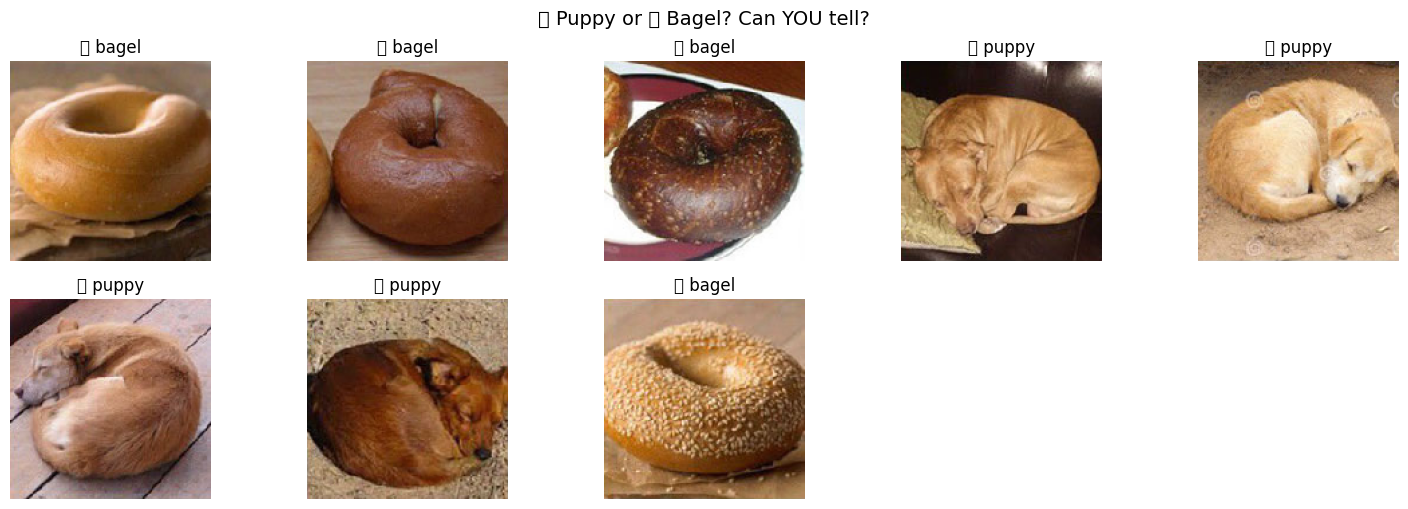

In [68]:
# ============================================================
# VISUALIZE SAMPLE IMAGES
#
# Let's see what our puppies and bagels look like!
# Can you tell which is which?
# ============================================================

def show_batch(generator, class_names, num=20):
    """Display a grid of images from the generator."""
    # Get one batch of images and labels
    images, labels = next(generator)

    # Create figure with subplots
    plt.figure(figsize=(15, 10))

    for i in range(min(num, len(images))):
        plt.subplot(4, 5, i + 1)  # 4 rows × 5 columns
        plt.imshow(images[i])      # Show the image

        # Add label with emoji
        label_idx = int(labels[i])
        emoji = '🐶' if class_names[label_idx] == 'puppy' else '🥯'
        plt.title(f"{emoji} {class_names[label_idx]}")
        plt.axis('off')  # Hide axes

    plt.suptitle("🐶 Puppy or 🥯 Bagel? Can YOU tell?", fontsize=14)
    plt.tight_layout()
    plt.show()

# Display sample images
show_batch(train_generator, class_names)

---
## 5. Part 1: Build a Custom CNN from Scratch 🏗️

Now it's YOUR turn to build a CNN! You'll complete several sections yourself.

### Our CNN Architecture Plan:
```
Input (150×150×3)
    ↓
Conv2D(32 filters) → ReLU → MaxPooling2D
    ↓
Conv2D(64 filters) → ReLU → MaxPooling2D
    ↓
Conv2D(128 filters) → ReLU → MaxPooling2D    ← YOU CODE THIS
    ↓
Conv2D(128 filters) → ReLU → MaxPooling2D    ← YOU CODE THIS
    ↓
Flatten
    ↓
Dense(512) → ReLU → Dropout(0.5)             ← YOU CODE THIS
    ↓
Dense(1) → Sigmoid                            ← YOU CODE THIS
    ↓
Output (0 = bagel, 1 = puppy)
```

In [69]:
# ============================================================
# BUILD CNN - STEP 1: CREATE MODEL AND FIRST TWO BLOCKS
#
# We'll start with Sequential API and add the first two
# convolutional blocks (provided for you as example)
# ============================================================

# Create a Sequential model - layers are added in order
model_custom = models.Sequential([

    # ========== FIRST CONVOLUTIONAL BLOCK ==========
    # Conv2D: Creates 32 different 3x3 filters to detect features
    # - 32 = number of filters (feature detectors)
    # - (3,3) = filter size (3x3 pixels)
    # - activation='relu' = ReLU makes negative values zero
    # - input_shape = (height, width, channels) for RGB images
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # MaxPooling: Reduces image size by taking max in 2x2 windows
    # This makes the model focus on the strongest features
    layers.MaxPooling2D((2, 2)),

    # ========== SECOND CONVOLUTIONAL BLOCK ==========
    # More filters (64) to detect more complex patterns
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
])

print("✅ Created model with first two convolutional blocks!")
print("\n📐 Current model architecture:")
model_custom.summary()

✅ Created model with first two convolutional blocks!

📐 Current model architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Add the Third Convolutional Block

**Task:** Add a convolutional block with **128 filters**

**What to add:**
1. `Conv2D` layer with 128 filters, (3,3) kernel, ReLU activation
2. `MaxPooling2D` layer with (2,2) pool size

**Syntax help:**
```python
model_custom.add(layers.Conv2D(num_filters, (3, 3), activation='relu'))
model_custom.add(layers.MaxPooling2D((2, 2)))
```

In [70]:
# ============================================================
# YOUR CODE HERE: ADD THE THIRD CONVOLUTIONAL BLOCK

# Instructions:
# 1. Add Conv2D with 128 filters, kernel (3,3), activation 'relu'
model_custom.add(layers.Conv2D(128, (3, 3), activation='relu')),
# 2. Add MaxPooling2D with pool size (2,2)
model_custom.add(layers.MaxPooling2D((2, 2))),

# ============================================================

# Third convolutional block - 128 filters
# HINT: model_custom.add(layers.Conv2D(???, (?, ?), activation='???'))



# HINT: model_custom.add(layers.MaxPooling2D((?, ?)))



print("Third block added! Check the summary below:")
model_custom.summary()

Third block added! Check the summary below:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Add the Fourth Convolutional Block

**Task:** Add another convolutional block with **128 filters** (same as third block)

In [71]:
# ============================================================
# YOUR CODE HERE: ADD THE FOURTH CONVOLUTIONAL BLOCK
#
# Same as the third block: Conv2D(128) + MaxPooling2D
# ============================================================

# Fourth convolutional block - 128 filters

model_custom.add(layers.Conv2D(128, (3, 3), activation = 'relu')),
model_custom.add(layers.MaxPooling2D((2, 2))),




print("Fourth block added! You should now have 4 conv2d layers:")
model_custom.summary()

Fourth block added! You should now have 4 conv2d layers:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,832 (940.75 KB)

 Trainable params: 240,832 (940.75 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Add the Classification Layers

Now we need to add the "head" of our network that makes the final classification decision.

**What to add (in order):**
1. `Flatten()` - Converts 2D feature maps to 1D vector
2. `Dense(512, activation='relu')` - Fully connected layer with 512 neurons
3. `Dropout(0.5)` - Randomly turns off 50% of neurons (prevents overfitting)
4. `Dense(1, activation='sigmoid')` - Output: probability of being a puppy

**Syntax help:**
```python
model_custom.add(layers.Flatten())
model_custom.add(layers.Dense(units, activation='relu'))
model_custom.add(layers.Dropout(rate))  # rate is between 0 and 1
```

In [72]:
# ============================================================
# YOUR CODE HERE: ADD THE CLASSIFICATION LAYERS
#
# Add these 4 layers in order:
# 1. Flatten()
# 2. Dense(512, activation='relu')
# 3. Dropout(0.5)
# 4. Dense(1, activation='sigmoid')
# ============================================================

# Flatten - converts 2D to 1D
# HINT: model_custom.add(layers.Flatten())
model_custom.add(layers.Flatten())


# Dense layer with 512 neurons
# HINT: model_custom.add(layers.Dense(???, activation='???'))
model_custom.add(layers.Dense(512, activation = 'relu'))


# Dropout for regularization (50% = 0.5)
# HINT: model_custom.add(layers.Dropout(???))
model_custom.add(layers.Dropout(0.5))


# Output layer - 1 neuron with sigmoid for binary classification
# Sigmoid outputs a probability between 0 and 1
# HINT: model_custom.add(layers.Dense(???, activation='???'))
model_custom.add(layers.Dense(1, activation = 'sigmoid'))



print("\n📐 COMPLETE MODEL ARCHITECTURE:")
model_custom.summary()


📐 COMPLETE MODEL ARCHITECTURE:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Compile the Model

Before training, we must **compile** the model to configure:
- **Optimizer**: How to update weights (use `'adam'`)
- **Loss function**: What to minimize (use `'binary_crossentropy'` for binary classification)
- **Metrics**: What to track (use `['accuracy']`)

**Syntax:**
```python
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
```

In [73]:
# ============================================================
# YOUR CODE HERE: COMPILE THE MODEL
#
# Use:
# - optimizer: 'adam'
# - loss: 'binary_crossentropy'
# - metrics: ['accuracy']
# ============================================================

# HINT: model_custom.compile(optimizer='???', loss='???', metrics=['???'])
model_custom.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])



print("✅ Model compiled and ready to train!")

✅ Model compiled and ready to train!


In [74]:
# ============================================================
# CALCULATE TRAINING STEPS
#
# steps_per_epoch = how many batches to process per epoch
# This is: total_samples ÷ batch_size
# ============================================================

steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = validation_generator.samples // BATCH_SIZE if validation_generator else None

print(f"📊 Training setup:")
print(f"   Total training images: {train_generator.samples}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Total epochs: {EPOCHS_CUSTOM}")

📊 Training setup:
   Total training images: 12
   Batch size: 8
   Steps per epoch: 1
   Total epochs: 12


In [75]:
# ============================================================
# SETUP CALLBACKS FOR SMARTER TRAINING
#
# Callbacks are functions that run during training:
# - EarlyStopping: Stop if no improvement (saves time!)
# - ModelCheckpoint: Save best model (important for Colab!)
# ============================================================

callbacks = [
    # EarlyStopping: Stop if validation loss doesn't improve
    keras.callbacks.EarlyStopping(
        monitor='val_loss',         # Watch this metric
        patience=5,                  # Wait 5 epochs for improvement
        restore_best_weights=True    # Go back to best weights
    ),

    # ModelCheckpoint: Save best model during training
    keras.callbacks.ModelCheckpoint(
        'best_custom_model.keras',   # Filename
        monitor='val_accuracy',       # Save when this improves
        save_best_only=True,          # Only keep the best
        verbose=1                     # Print when saving
    )
]

print("✅ Callbacks configured!")

✅ Callbacks configured!


In [76]:
# ============================================================
# TRAIN THE CUSTOM CNN
#
# This is where the magic happens!
# The model learns from the training data over multiple epochs.
# Watch the accuracy improve!
# ============================================================

print("\n🚀 Training the Puppy vs Bagel classifier...")
print("   This may take several minutes.\n")

history_custom = model_custom.fit(
    train_generator,                     # Training data
    steps_per_epoch=steps_per_epoch,     # Batches per epoch
    epochs=EPOCHS_CUSTOM,                # Number of epochs
    validation_data=validation_generator, # Validation data
    validation_steps=validation_steps,   # Validation batches
    callbacks=callbacks,                 # Our callbacks
    verbose=1                            # Show progress
)

print("\n✅ Training complete!")


🚀 Training the Puppy vs Bagel classifier...
   This may take several minutes.

Epoch 1/12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7500 - loss: 0.6714
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_custom_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.7500 - loss: 0.6714 - val_accuracy: 0.5000 - val_loss: 0.9735
Epoch 2/12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3750 - loss: 1.0464
Epoch 2: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3750 - loss: 1.0464 - val_accuracy: 0.5000 - val_loss: 0.6889
Epoch 3/12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.7323
Epoch 3: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5000 - loss: 0.7323 - val_accuracy: 0.5000 - val_loss: 0.6881
Epoch 4/12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7500 - loss: 0.6487
Epoch 4: val_accuracy did not improve from 0.50000
1/1 ━━━━

/tmp/ipython-input-274693214.py:36: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-274693214.py:36: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


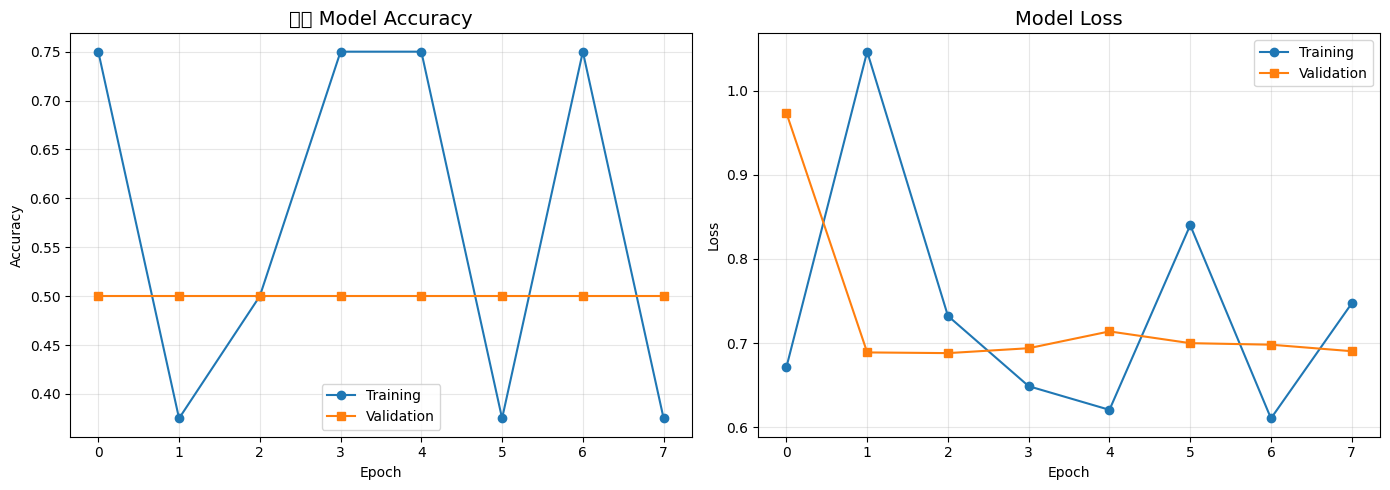


📊 How to read these plots:
   • Lines close together = Good generalization
   • Validation worse than training = Overfitting
   • Both lines plateau = Model has converged


In [77]:
# ============================================================
# VISUALIZE TRAINING HISTORY
#
# These plots help us understand how training went:
# - Accuracy plot: Should increase over time
# - Loss plot: Should decrease over time
# - Gap between train/val lines indicates overfitting
# ============================================================

import matplotlib.pyplot as plt

hist = history_custom.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(hist.get('accuracy', []), label='Training', marker='o')
if 'val_accuracy' in hist:
    ax1.plot(hist['val_accuracy'], label='Validation', marker='s')
ax1.set_title('🐶🥯 Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(hist.get('loss', []), label='Training', marker='o')
if 'val_loss' in hist:
    ax2.plot(hist['val_loss'], label='Validation', marker='s')
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 How to read these plots:")
if 'val_accuracy' in hist:
    print("   • Lines close together = Good generalization")
    print("   • Validation worse than training = Overfitting")
else:
    print("   • No validation curves shown (you didn’t pass validation_data to fit())")
print("   • Both lines plateau = Model has converged")


In [78]:
# ============================================================
# EVALUATE ON TEST SET
#
# The true test of our model - how well does it perform
# on images it has never seen before?
# ============================================================

if test_generator:
    test_generator.reset()  # Reset to start of test data
    test_loss, test_acc = model_custom.evaluate(test_generator, verbose=0)

    print(f"\n📊 Custom CNN Results:")
    print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"   Test Loss: {test_loss:.4f}")


📊 Custom CNN Results:
   Test Accuracy: 0.5000 (50.00%)
   Test Loss: 0.6881


---
## 6. Part 2: Transfer Learning with Pre-trained Models

Transfer learning uses models already trained on millions of images. We just add our own classification layers on top! This usually gives better results with less training time.

### ⚠️ Colab Free Tier Tips:
If you get **"Out of Memory"** errors:
1. Set `USE_MOBILENET = True` below (smaller model)
2. Restart runtime: Runtime → Restart runtime

In [79]:
# ============================================================
# CHOOSE YOUR PRE-TRAINED MODEL
#
# MobileNetV2: Smaller, faster (good for Colab Free)
# ResNet50: Larger, more powerful
# ============================================================

# Change to True if you're running out of memory!
USE_MOBILENET = False

if USE_MOBILENET:
    IMG_SIZE_TRANSFER = 128
    print("📱 Using MobileNetV2 (lightweight, great for Colab Free)")
else:
    IMG_SIZE_TRANSFER = 224
    print("🔬 Using ResNet50 (powerful, needs more memory)")

🔬 Using ResNet50 (powerful, needs more memory)


In [81]:
# ============================================================
# CREATE DATA GENERATORS FOR TRANSFER LEARNING (CORRECT VERSION)
# Uses validation_split instead of valid_dir / test_dir
# ============================================================

IMG_SIZE_TRANSFER = 224
VAL_SPLIT = 0.25
SEED = 123

train_gen_tf = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset="training",
    seed=SEED
)

val_gen_tf = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset="validation",
    seed=SEED,
    shuffle=False
)

# Use validation set as test set (dataset too small for true test)
test_gen_tf = val_gen_tf

print(f"✅ Created generators for {IMG_SIZE_TRANSFER}×{IMG_SIZE_TRANSFER} images")
print("   Train images:", train_gen_tf.samples)
print("   Val/Test images:", val_gen_tf.samples)


Found 12 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
✅ Created generators for 224×224 images
   Train images: 12
   Val/Test images: 4


In [82]:
# ============================================================
# LOAD THE PRE-TRAINED MODEL
#
# Key parameters:
# - weights='imagenet': Use weights trained on ImageNet
# - include_top=False: Remove original classification layers
# - trainable=False: Freeze weights (don't update during training)
# ============================================================

if USE_MOBILENET:
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER, 3)
    )
    model_name = "MobileNetV2"
else:
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER, 3)
    )
    model_name = "ResNet50"

# Freeze the base model - we won't train these layers
base_model.trainable = False

print(f"✅ Loaded {model_name}")
print(f"   Total layers: {len(base_model.layers)}")
print(f"   All layers frozen (won't be trained)")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Loaded ResNet50
   Total layers: 175
   All layers frozen (won't be trained)


In [83]:
# ============================================================
# BUILD TRANSFER LEARNING MODEL
#
# We add our own classification layers on top:
# - GlobalAveragePooling2D: Reduces feature maps to vectors
# - Dense: Our classification layers
# ============================================================

model_transfer = models.Sequential([
    # Pre-trained base (frozen)
    base_model,

    # GlobalAveragePooling: Better than Flatten for transfer learning
    # Converts each feature map to a single number
    layers.GlobalAveragePooling2D(),

    # Our custom classification layers
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile
model_transfer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"\n📐 {model_name} Transfer Learning Model:")
model_transfer.summary()


📐 ResNet50 Transfer Learning Model:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [84]:
# ============================================================
# TRAIN TRANSFER LEARNING MODEL
#
# Training is MUCH faster because we only train a few layers!
# The pre-trained layers already know how to detect features.
# ============================================================

steps_tf = train_gen_tf.samples // BATCH_SIZE
val_steps_tf = val_gen_tf.samples // BATCH_SIZE if valid_dir else None

callbacks_tf = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('best_transfer_model.keras', monitor='val_accuracy',
                                    save_best_only=True, verbose=1)
]

print(f"\n🚀 Training {model_name} with Transfer Learning...\n")

history_transfer = model_transfer.fit(
    train_gen_tf,
    steps_per_epoch=steps_tf,
    epochs=EPOCHS_TRANSFER,
    validation_data=val_gen_tf if valid_dir else None,
    validation_steps=val_steps_tf,
    callbacks=callbacks_tf,
    verbose=1
)

print("\n✅ Transfer learning complete!")


🚀 Training ResNet50 with Transfer Learning...

Epoch 1/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.6250 - loss: 0.7396
Epoch 2/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5000 - loss: 0.9247
Epoch 3/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 822ms/step - accuracy: 0.3750 - loss: 0.6962
Epoch 4/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.2384  
Epoch 5/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6250 - loss: 0.6722  
Epoch 6/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step - accuracy: 0.7500 - loss: 0.5348
Epoch 7/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step - accuracy: 0.3750 - loss: 0.7319
Epoch 8/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step - accuracy: 0.7500 - loss: 0.6493

✅ Transfer learning complete!


In [85]:
# ============================================================
# EVALUATE TRANSFER LEARNING MODEL
# ============================================================

test_gen_tf.reset()
test_loss_tf, test_acc_tf = model_transfer.evaluate(test_gen_tf, verbose=0)

print(f"\n📊 {model_name} Transfer Learning Results:")
print(f"   Test Accuracy: {test_acc_tf:.4f} ({test_acc_tf*100:.2f}%)")
print(f"   Test Loss: {test_loss_tf:.4f}")


📊 ResNet50 Transfer Learning Results:
   Test Accuracy: 0.5000 (50.00%)
   Test Loss: 0.6891


---
## 7. Compare Results

In [86]:
# ============================================================
# CREATE COMPARISON TABLE
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Custom CNN', f'Transfer ({model_name})'],
    'Test Accuracy': [f"{test_acc*100:.2f}%", f"{test_acc_tf*100:.2f}%"],
    'Test Loss': [f"{test_loss:.4f}", f"{test_loss_tf:.4f}"],
    'Epochs': [len(history_custom.history['loss']), len(history_transfer.history['loss'])]
})

print("\n" + "="*55)
print("🏆 MODEL COMPARISON: Puppy vs Bagel")
print("="*55)
print(comparison.to_string(index=False))
print("="*55)


🏆 MODEL COMPARISON: Puppy vs Bagel
              Model Test Accuracy Test Loss  Epochs
         Custom CNN        50.00%    0.6881       8
Transfer (ResNet50)        50.00%    0.6891       8


---
## 8. Visualize Predictions

/tmp/ipython-input-1739210353.py:32: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1739210353.py:32: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1739210353.py:32: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

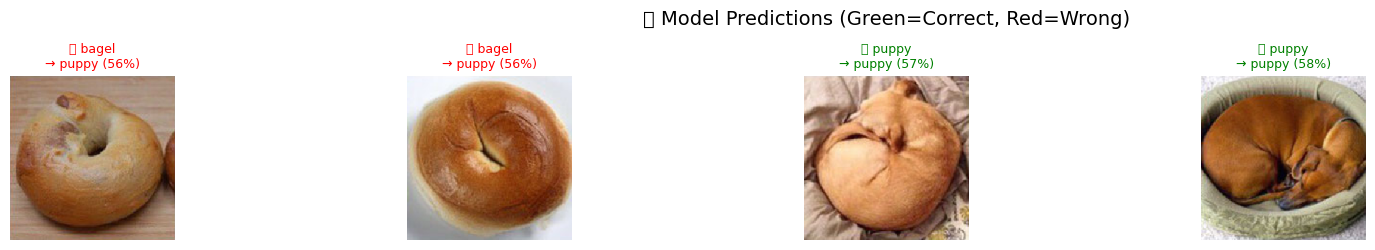

In [87]:
# ============================================================
# VISUALIZE MODEL PREDICTIONS
#
# Green title = Correct prediction
# Red title = Wrong prediction
# ============================================================

test_gen_tf.reset()
images, labels = next(test_gen_tf)
preds = model_transfer.predict(images[:20], verbose=0)

plt.figure(figsize=(20, 8))
for i in range(min(20, len(images))):
    plt.subplot(4, 5, i + 1)
    plt.imshow(images[i])

    # Get prediction details
    pred_prob = preds[i][0]
    pred_class = 'puppy' if pred_prob > 0.5 else 'bagel'
    true_class = class_names[int(labels[i])]
    confidence = pred_prob if pred_prob > 0.5 else 1 - pred_prob

    # Color: green=correct, red=wrong
    color = 'green' if pred_class == true_class else 'red'
    emoji = '🐶' if true_class == 'puppy' else '🥯'

    plt.title(f"{emoji} {true_class}\n→ {pred_class} ({confidence:.0%})",
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('🔍 Model Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. Confusion Matrix

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


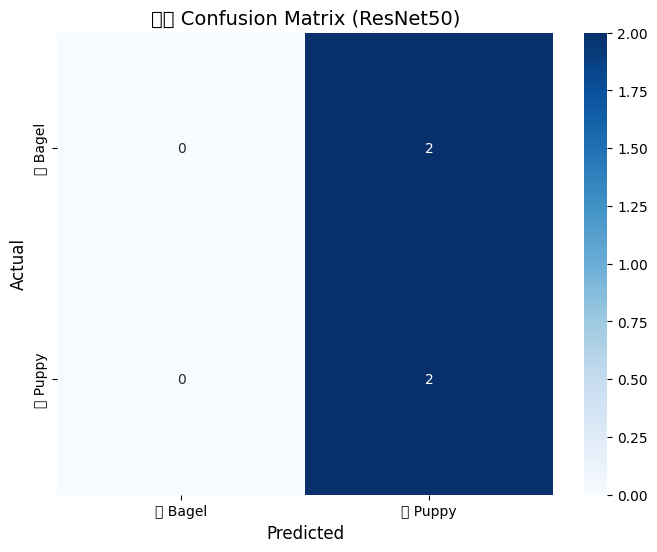


📋 Classification Report:
              precision    recall  f1-score   support

       Bagel       0.00      0.00      0.00         2
       Puppy       0.50      1.00      0.67         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [88]:
# ============================================================
# GENERATE CONFUSION MATRIX
#
# Shows where the model gets confused:
# - Diagonal = correct predictions
# - Off-diagonal = errors
# ============================================================

test_gen_tf.reset()
y_pred = (model_transfer.predict(test_gen_tf, verbose=0) > 0.5).astype(int).flatten()
y_true = test_gen_tf.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['🥯 Bagel', '🐶 Puppy'],
            yticklabels=['🥯 Bagel', '🐶 Puppy'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'🐶🥯 Confusion Matrix ({model_name})', fontsize=14)
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Bagel', 'Puppy']))

---
## 10. Reflective Questions

### Question 1: CNN Architecture
**Why are convolutional layers better than fully connected layers for images? How do they help distinguish puppies from bagels?**

Your answer:
Convolutional layers are better than fully connected layers for images because they preserve spatial structure and learn local patterns.
Images have spatial relationships (edges, shapes, textures). Convolutional layers use small filters that slide over the image, allowing the model to detect features like edges, curves, and textures regardless of position.
They use far fewer parameters than fully connected layers, making them more efficient and less prone to overfitting.
For puppies vs bagels:
Early convolutional layers can detect edges and textures (fur vs smooth bread).
Deeper layers can learn shapes (irregular animal forms vs circular bagels).
Fully connected layers alone would ignore spatial structure and struggle to capture these visual cues.

---

### Question 2: Data Augmentation  
**Why did we use data augmentation for training? How does rotation, flipping, and zooming help the model learn?**

Your answer:
Data augmentation is used to artificially increase dataset diversity and reduce overfitting.
With a small dataset, the model can memorize images instead of learning general features.
Augmentation creates new variations of existing images without changing their labels.
How it helps:
Rotation helps the model recognize objects at different orientations.
Flipping teaches the model that left/right orientation doesn’t change the class.
Zooming helps the model focus on important features at different scales.
Overall, augmentation helps the model learn robust, generalizable features instead of memorizing exact images.

---

### Question 3: Transfer Learning
**Why does transfer learning often achieve better results than training from scratch, especially with small datasets?**

Your answer:
Transfer learning performs better than training from scratch because it reuses knowledge learned from large, diverse datasets.
Pretrained models have already learned general visual features (edges, textures, shapes) from millions of images.
With a small dataset, training from scratch cannot reliably learn these features.
By starting from pretrained weights, the model only needs to learn the task-specific differences (e.g., puppy vs bagel), which requires far less data and reduces overfitting.

---

### Question 4: Model Comparison
**Which model performed better in your experiment? What factors explain the difference?**

Your answer: In this experiment, neither model clearly outperformed the other; both the custom CNN and the ResNet50 transfer learning model achieved about 50% accuracy.
The lack of performance difference is explained by:
Extremely small dataset size, which limited the ability of both models to generalize.
Very small validation/test sets, where a single misclassification significantly affects accuracy.
High variance during training, causing unstable learning.
As a result, the benefits of transfer learning could not be realized under these data constraints.


---

### Question 5: Challenging Cases
**Looking at the predictions, what visual features might make puppies look like bagels (or vice versa)?**

Your answer:
Especially with limited data, several visual similarities can confuse the model and make puppies look like bagels (or vice versa), such as round shape, similarity in color, texture ambiguity, background noise, and the scale and frame in which the picture is taken.

---
## 11. Student Challenge: Fine-tune the Model

**Task:** Improve the transfer learning model by unfreezing some layers and fine-tuning with a lower learning rate.

In [89]:
# ============================================================
# YOUR CODE HERE: FINE-TUNE THE TRANSFER LEARNING MODEL
#
# Steps:
# 1. Unfreeze the base model: base_model.trainable = True
# 2. Freeze early layers: for layer in base_model.layers[:-30]: layer.trainable = False
# 3. Recompile with lower learning rate: Adam(learning_rate=0.0001)
# 4. Train for 5 more epochs
# 5. Evaluate and compare
# ============================================================

# Step 1: Unfreeze the base model
base_model.trainable = True

# Step 2: Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Step 3: Recompile with lower learning rate (important!)
model_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 4: Train for 5 more epochs
history_ft = model_transfer.fit(
    train_gen_tf,
    steps_per_epoch=steps_tf,
    epochs=5,
    validation_data=val_gen_tf,
    validation_steps=val_steps_tf,
    verbose=1
)

# Step 5: Evaluate
test_gen_tf.reset()
_, acc_ft = model_transfer.evaluate(test_gen_tf)
print(f"\nFine-tuned Accuracy: {acc_ft*100:.2f}%")

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step - accuracy: 0.5000 - loss: 0.7513 - val_accuracy: 0.5000 - val_loss: 0.6856
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.2500 - loss: 1.1886 - val_accuracy: 0.5000 - val_loss: 0.6867
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7500 - loss: 0.5064 - val_accuracy: 0.5000 - val_loss: 0.6894
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.2500 - loss: 0.8182 - val_accuracy: 0.5000 - val_loss: 0.6905
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.2500 - loss: 0.6878 - val_accuracy: 0.5000 - val_loss: 0.6897
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5000 - loss: 0.6897

Fine-tuned Accuracy: 50.00%


**Challenge Question:** Did fine-tuning improve performance? Why or why not?

Your answer:
No, it did not, and there are a few reasons for this.
Firstly, we used an extremely small dataset and thus the model behaved very unstably as opposed to learning from patterns. Second, the validation set was very small. Third, there was a lot of variance during training. The accuracy of the model greatly fluctuated during training, meaning it was just look at individual instances as opposed to learning consistently.

---
## 12. Save Your Model

In [90]:
# ============================================================
# SAVE THE TRAINED MODEL
#
# Important for Colab - download before your session ends!
# ============================================================

model_transfer.save('puppy_bagel_classifier.keras')
print("✅ Model saved as 'puppy_bagel_classifier.keras'")

# Download in Colab
if IN_COLAB:
    from google.colab import files
    files.download('puppy_bagel_classifier.keras')
    print("📥 Model downloaded to your computer!")

✅ Model saved as 'puppy_bagel_classifier.keras'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Model downloaded to your computer!


---
## Submission Checklist

**Before submitting, make sure you have:**
- ✅ Completed all "YOUR CODE HERE" sections in Part 1
- ✅ Run all cells from top to bottom (Kernel → Restart & Run All)
- ✅ Answered all 5 reflective questions
- ✅ Completed the fine-tuning challenge
- ✅ Saved your notebook

**Filename:** `Module_03_Lab_YourName.ipynb`

---
**Congratulations!** 🎉 You built a CNN that can tell puppies from bagels! 🐶🥯

---
## Resources

**Dataset:**
- Puppy or Bagel: https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel

**Alternative Fun Datasets:**
- Muffin vs Chihuahua: https://www.kaggle.com/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification
- Corgi Butt vs Bread: https://github.com/Kawaeee/butt_or_bread

**Original Meme Creator:** Karen Zack (@teenybiscuit)